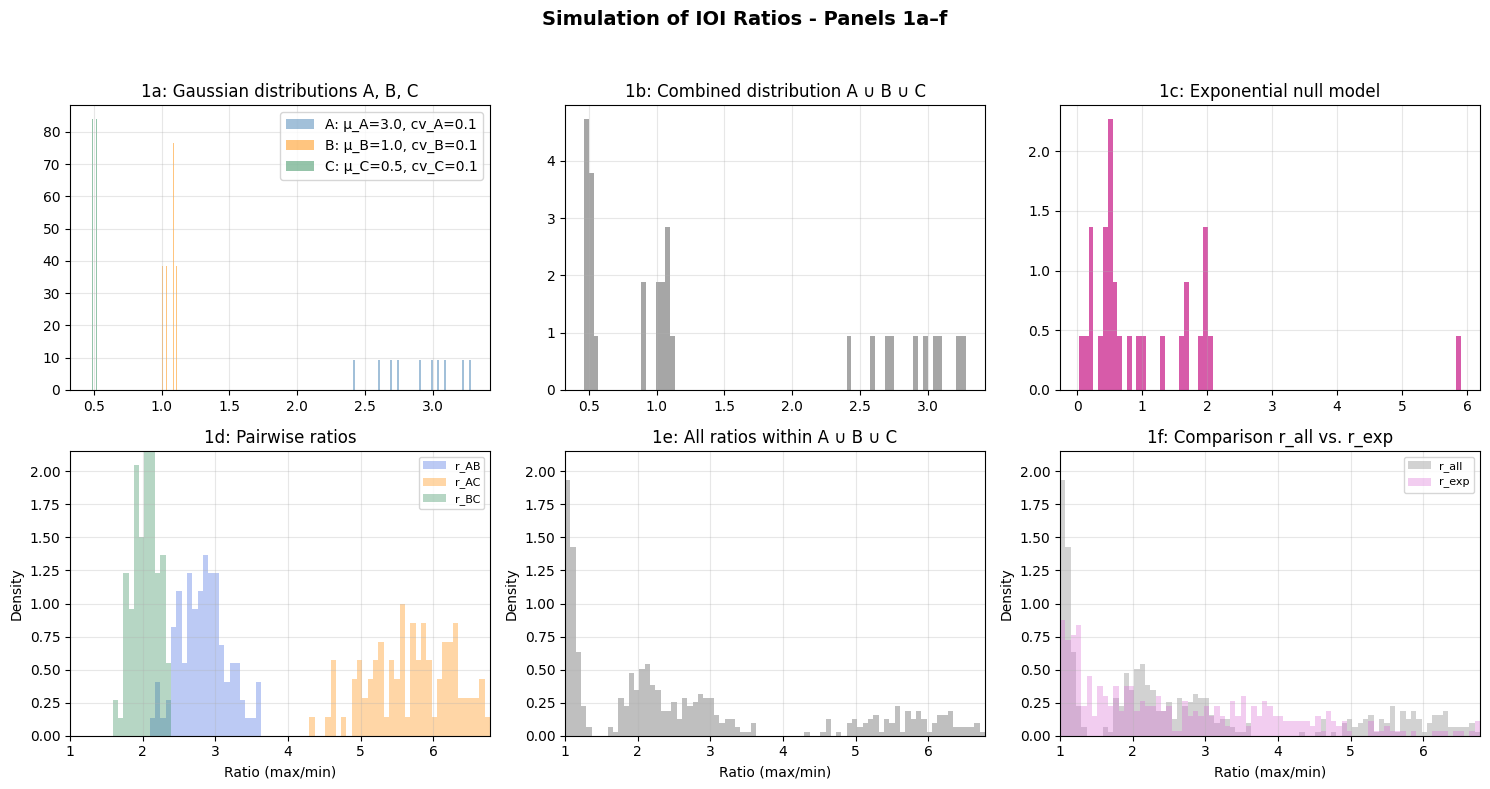

In [2]:
# plot for introduction and simulation of IOI ratio distributions
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_ratio_panel_abc(
    sample_size=600,
    means=(30.2, 20.0, 10.0),
    cvs=(0.1, 0.13, 0.15),
    bins=80,
    random_seed=42,
    show_kde=True
):
    rng = np.random.default_rng(random_seed)

    # --- Drei Normalverteilungen ---
    stds = [m*c for m,c in zip(means, cvs)]
    A = rng.normal(means[0], stds[0], sample_size)
    B = rng.normal(means[1], stds[1], sample_size)
    C = rng.normal(means[2], stds[2], sample_size)

    all_values = np.concatenate([A, B, C])

    # Ratio-Funktion
    def ratio_pairs_unique(x, y):
        """Berechnet eindeutige Ratios (ohne Selbstvergleiche oder Dopplungen)."""
        x = np.asarray(x)
        y = np.asarray(y)
        if np.array_equal(x, y):
            # gleiche Liste → obere Dreiecksmatrix ohne Diagonale
            i_idx, j_idx = np.triu_indices(len(x), k=1)
            r = x[i_idx] / y[j_idx]
        else:
            # unterschiedliche Listen → alle Kombinationen
            r = x[:, None] / y[None, :]
            r = r.ravel()
        r = np.maximum(r, 1 / r)
        return r

    # --- Exponential Null-Modell ---
    mean_all = all_values.mean()
    E = rng.exponential(scale=mean_all, size=len(all_values))

    # --- Ratios ---
    r_AB = ratio_pairs_unique(A, B)
    r_AC = ratio_pairs_unique(A, C)
    r_BC = ratio_pairs_unique(B, C)
    r_all = ratio_pairs_unique(all_values, all_values)
    r_exp = ratio_pairs_unique(E, E)

    # X-Achse für untere Reihe
    x_min = 1
    x_max = np.percentile(np.concatenate([r_AB, r_AC, r_BC, r_all]), 99)
    bins_lin = np.linspace(x_min, x_max, bins)

    fig, axs = plt.subplots(2, 3, figsize=(15,8))
    fig.suptitle("Simulation of IOI Ratios - Panels 1a–f", fontsize=14, weight="bold")

    # --- Top row ---
    # 1a: Drei Gaussianen
    axs[0,0].hist(A, bins=bins, density=True, alpha=0.5, color="steelblue", label=f"A: µ_A={means[0]}, cv_A={cvs[0]}")
    axs[0,0].hist(B, bins=bins, density=True, alpha=0.5, color="darkorange", label=f"B: µ_B={means[1]}, cv_B={cvs[1]}")
    axs[0,0].hist(C, bins=bins, density=True, alpha=0.5, color="seagreen", label=f"C: µ_C={means[2]}, cv_C={cvs[2]}")
    axs[0,0].set_title("1a: Gaussian distributions A, B, C")
    axs[0,0].legend()
    axs[0,0].grid(alpha=0.3)

    # 1b: Kombinierte Verteilung
    axs[0,1].hist(all_values, bins=bins, density=True, alpha=0.7, color="gray")
    axs[0,1].set_title("1b: Combined distribution A ∪ B ∪ C")
    axs[0,1].grid(alpha=0.3)

    # 1c: Exponential
    axs[0,2].hist(E, bins=bins, density=True, alpha=0.7, color="mediumvioletred")
    axs[0,2].set_title("1c: Exponential null model")
    axs[0,2].grid(alpha=0.3)

    # --- Bottom row ---
    # 1d: Paarweise Ratios
    ax = axs[1,0]
    for r,color,label in zip([r_AB, r_AC, r_BC], ["royalblue","darkorange","seagreen"], ["r_AB","r_AC","r_BC"]):
        ax.hist(r, bins=bins_lin, density=True, alpha=0.35, color=color, label=label)
        if show_kde:
            kde = gaussian_kde(r)
            x_grid = np.linspace(x_min, x_max, 1000)
            ax.plot(x_grid, kde(x_grid), color=color, lw=2)
    ax.set_title("1d: Pairwise ratios")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # 1e: Alle-mit-allen Ratios
    ax = axs[1,1]
    ax.hist(r_all, bins=bins_lin, density=True, alpha=0.5, color="gray")
    if show_kde:
        kde = gaussian_kde(r_all)
        x_grid = np.linspace(x_min, x_max, 1000)
        ax.plot(x_grid, kde(x_grid), color="black", lw=2)
    ax.set_title("1e: All ratios within A ∪ B ∪ C")
    ax.grid(alpha=0.3)

    # 1f: Vergleich All vs. Exponential
    ax = axs[1,2]
    ax.hist(r_all, bins=bins_lin, density=True, alpha=0.35, color="gray", label="r_all")
    ax.hist(r_exp, bins=bins_lin, density=True, alpha=0.35, color="orchid", label="r_exp")
    if show_kde:
        kde_all = gaussian_kde(r_all)
        kde_exp = gaussian_kde(r_exp[r_exp<x_max])
        x_grid = np.linspace(x_min, x_max, 1000)
        ax.plot(x_grid, kde_all(x_grid), color="black", lw=2)
        ax.plot(x_grid, kde_exp(x_grid), color="purple", lw=2, ls="--")
    ax.set_title("1f: Comparison r_all vs. r_exp")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # --- Gemeinsame X- und Y-Achsen für untere Reihe ---
    densities = []
    for r in [r_AB, r_AC, r_BC, r_all, r_exp]:
        kde = gaussian_kde(r[r<x_max])
        densities.append(kde(np.linspace(x_min,x_max,500)).max())
    y_max = max(densities)*1.05

    for ax in axs[1,:]:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(0, y_max)
        ax.set_xlabel("Ratio (max/min)")
        ax.set_ylabel("Density")

    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# Beispielaufruf
plot_ratio_panel_abc(
    sample_size=10,
    means=(3.0, 1.0, 0.5),
    cvs=(0.1, 0.1, 0.1),
    random_seed=42,
    show_kde=False
)


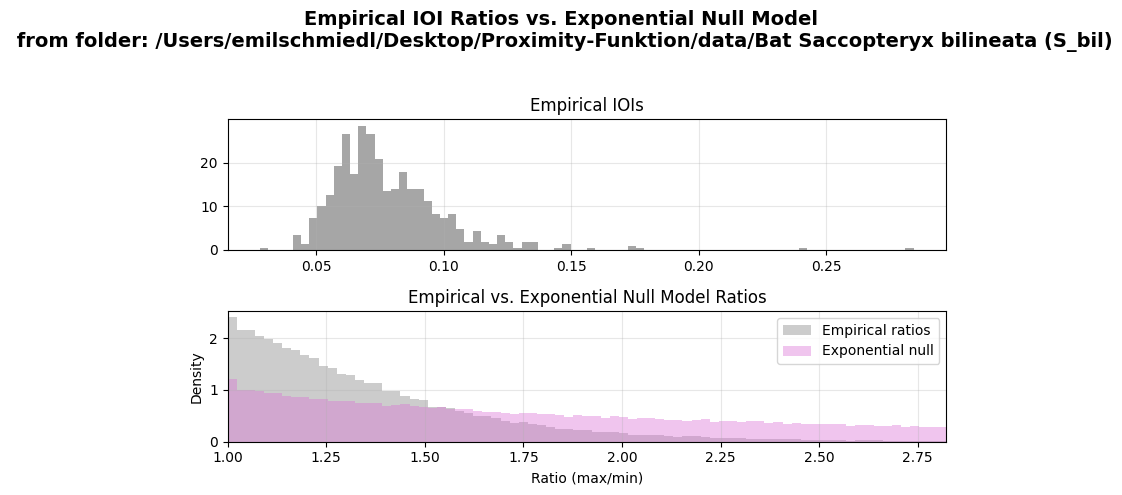

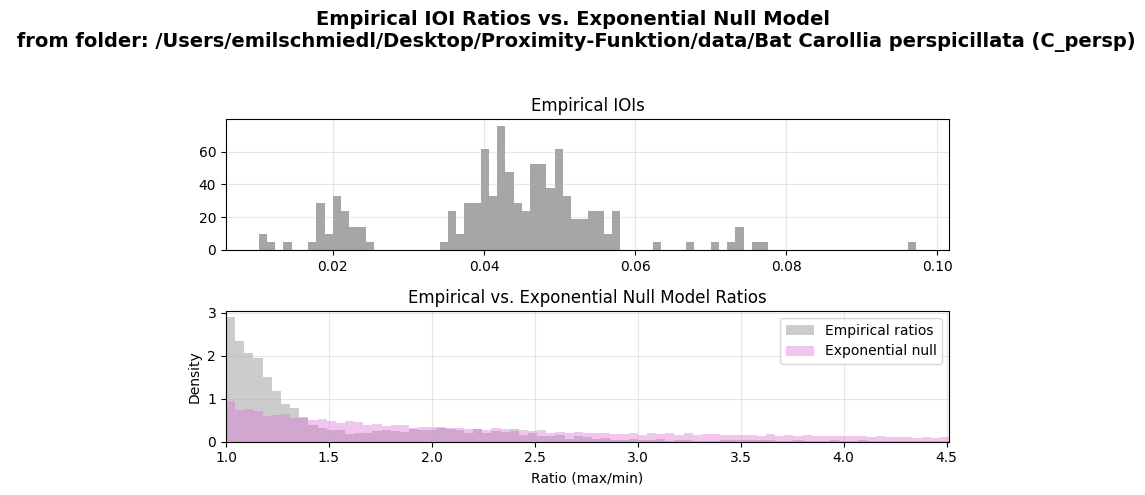

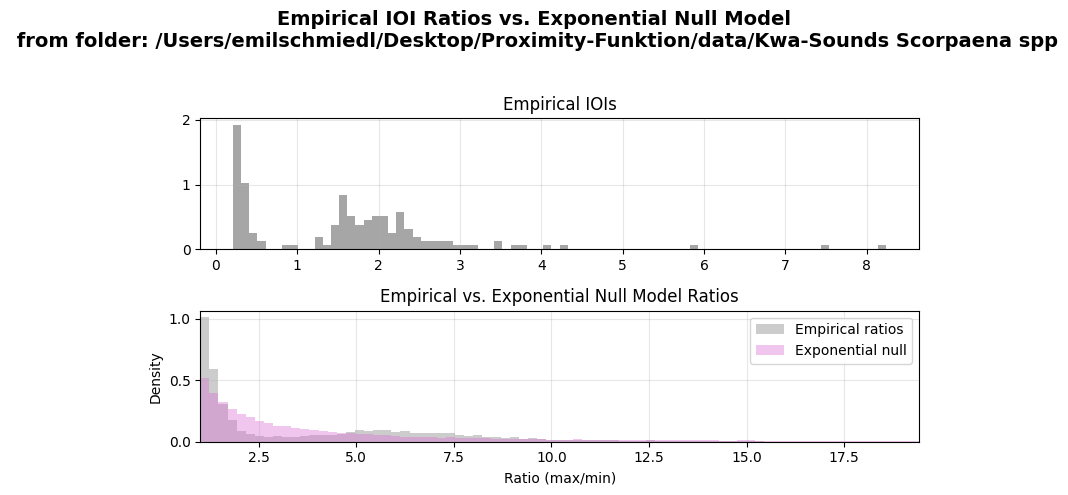

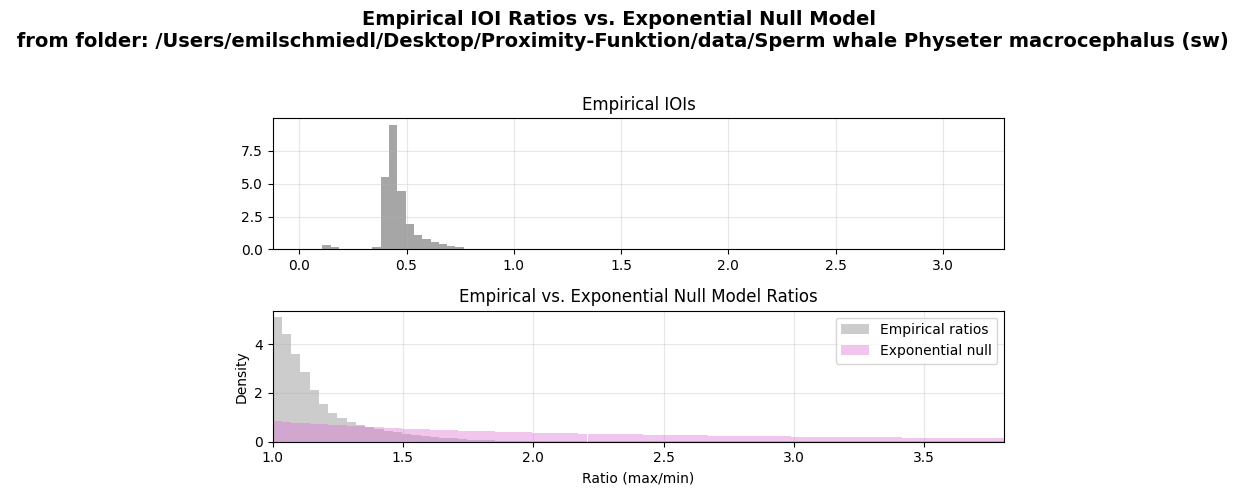

In [ ]:
# wie oben nur aus CSV-Dateien in einem Ordner
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import gaussian_kde

def plot_ratio_panel_from_folder(
    folder_path,
    bins=80,
    show_kde=True,
    random_seed=42
):
    """
    Reads all CSV files in a folder, extracts 'IOI' column values,
    and plots ratio distributions (empirical vs. exponential null model).
    """
    rng = np.random.default_rng(random_seed)

    # --- Alle CSV-Dateien im Ordner einlesen ---
    all_iois = []
    for file in os.listdir(folder_path):
        if file.lower().endswith(".csv"):
            path = os.path.join(folder_path, file)
            df = pd.read_csv(path)
            if "IOI" in df.columns:
                iois = df["IOI"].dropna().values
                all_iois.append(iois)
                #print(f"Loaded {len(iois)} IOIs from {file}")
            else:
                print(f"⚠️ Skipping {file}: no 'IOI' column found.")
    
    if not all_iois:
        raise ValueError("No valid CSV files with 'IOI' column found in folder.")

    # --- Kombinierte IOIs ---
    all_values = np.concatenate(all_iois)
    mean_all = np.mean(all_values)

    # --- Ratio-Funktion ---
    def ratio_pairs(x, y):
        r = (x[:, None] / y[None, :]).ravel()
        r = np.maximum(r, 1/r)
        return r

    # --- Ratios der kombinierten IOIs ---
    r_all = ratio_pairs(all_values, all_values)

    # --- Exponentielles Nullmodell ---
    E = rng.exponential(scale=mean_all, size=len(all_values))
    r_exp = ratio_pairs(E, E)

    # --- Plot-Setup ---
    x_min = 1
    x_max = np.percentile(r_all, 99)
    bins_lin = np.linspace(x_min, x_max, bins)

    fig, axs = plt.subplots(2, 1, figsize=(8, 5))
    fig.suptitle(f"Empirical IOI Ratios vs. Exponential Null Model\n from folder: {folder_path}", fontsize=14, weight="bold")

    # 1b: Kombinierte Verteilung
    ax = axs[0]
    ax.hist(all_values, bins=bins, density=True, alpha=0.7, color="gray")
    ax.set_title("Empirical IOIs")
    ax.grid(alpha=0.3)

    # --- Histogramme ---
    ax = axs[1]
    ax.hist(r_all, bins=bins_lin, density=True, alpha=0.4, color="gray", label="Empirical ratios")
    ax.hist(r_exp, bins=bins_lin, density=True, alpha=0.4, color="orchid", label="Exponential null")
    ax.set_title("Empirical vs. Exponential Null Model Ratios")

    # --- KDEs ---
    if show_kde:
        kde_all = gaussian_kde(r_all[r_all < x_max])
        kde_exp = gaussian_kde(r_exp[r_exp < x_max])
        x_grid = np.linspace(x_min, x_max, 1000)
        ax.plot(x_grid, kde_all(x_grid), color="black", lw=2)
        ax.plot(x_grid, kde_exp(x_grid), color="purple", lw=2, ls="--")

    ax.set_xlim(x_min, x_max)
    ax.set_xlabel("Ratio (max/min)")
    ax.set_ylabel("Density")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Beispielaufruf:
plot_ratio_panel_from_folder("/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Bat Saccopteryx bilineata (S_bil)", show_kde=False)
plot_ratio_panel_from_folder("/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Kwa-Sounds Scorpaena spp", show_kde=False)
plot_ratio_panel_from_folder("/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Sperm whale Physeter macrocephalus (sw)", show_kde=False)


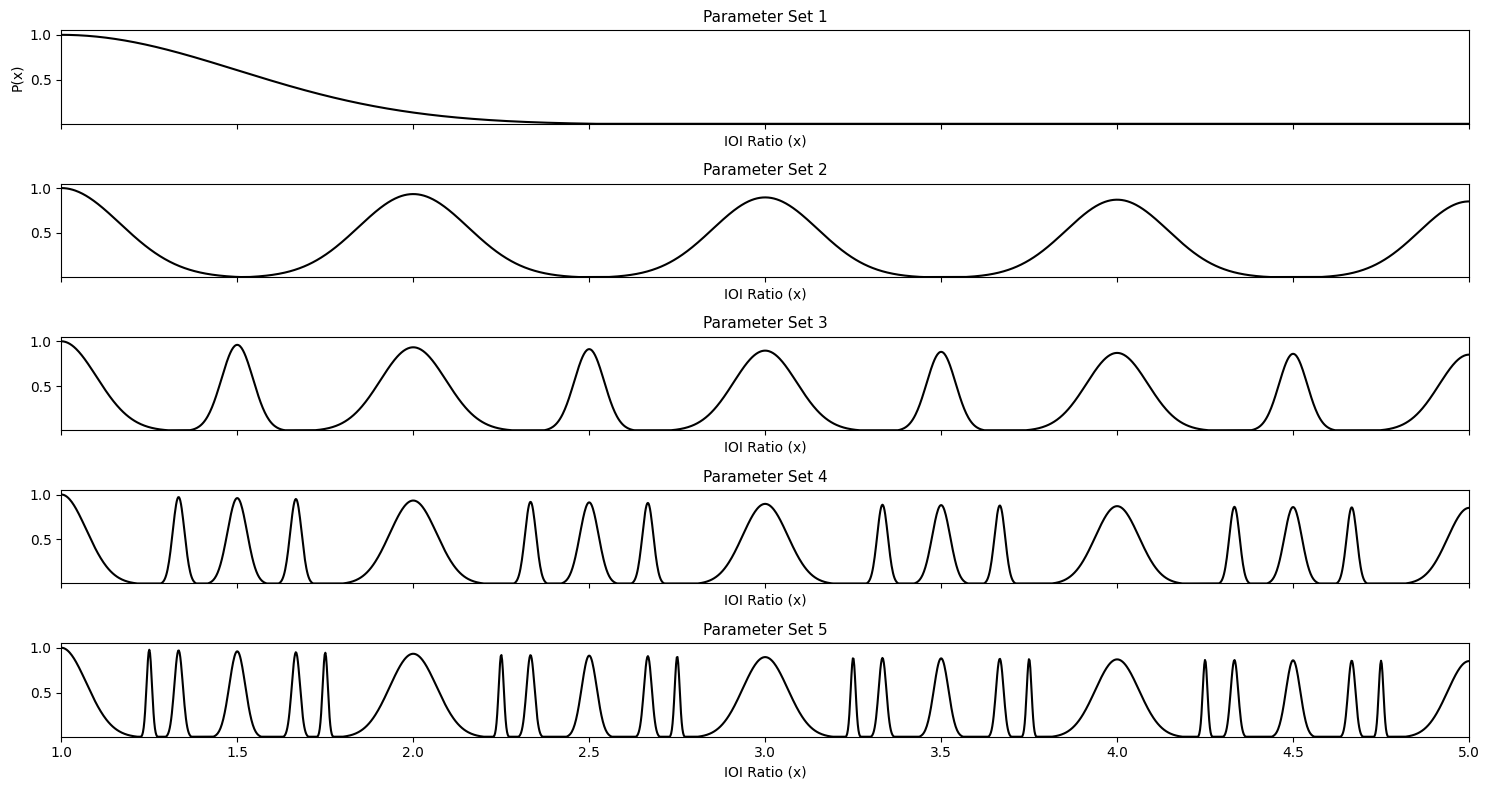

In [31]:
# plot for param-set study
import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path

# übergeordneten Ordner hinzufügen
sys.path.append(str(Path("..").resolve()))  # geht eine Ebene hoch

import importlib
import proximitylib.proximity as prox
importlib.reload(prox)

# =============================
# Compact overlay plot
# =============================
x = np.linspace(1, 5, 2000)

fig, axs = plt.subplots(5, 1, figsize=(15,8), sharex=True, sharey=True)
for idx, params in prox.param_sets.items():
    y, _ = prox.proximity_max_freq_gaussian_table(x, **params)
    axs[idx-1].plot(x, y, color="black", lw=1.5)
    axs[idx-1].set_title(f"Parameter Set {idx}", fontsize=11)
    axs[idx-1].set_xlabel("IOI Ratio (x)", fontsize=10)
    if idx == 1:
        axs[idx-1].set_ylabel("P(x)", fontsize=10)      
    axs[idx-1].set_xlim(x.min(), x.max())
    axs[idx-1].set_ylim(params["threshold"], 1.05)    
    
    plt.grid(False)
    plt.box(True)
    
plt.tight_layout()
plt.show()

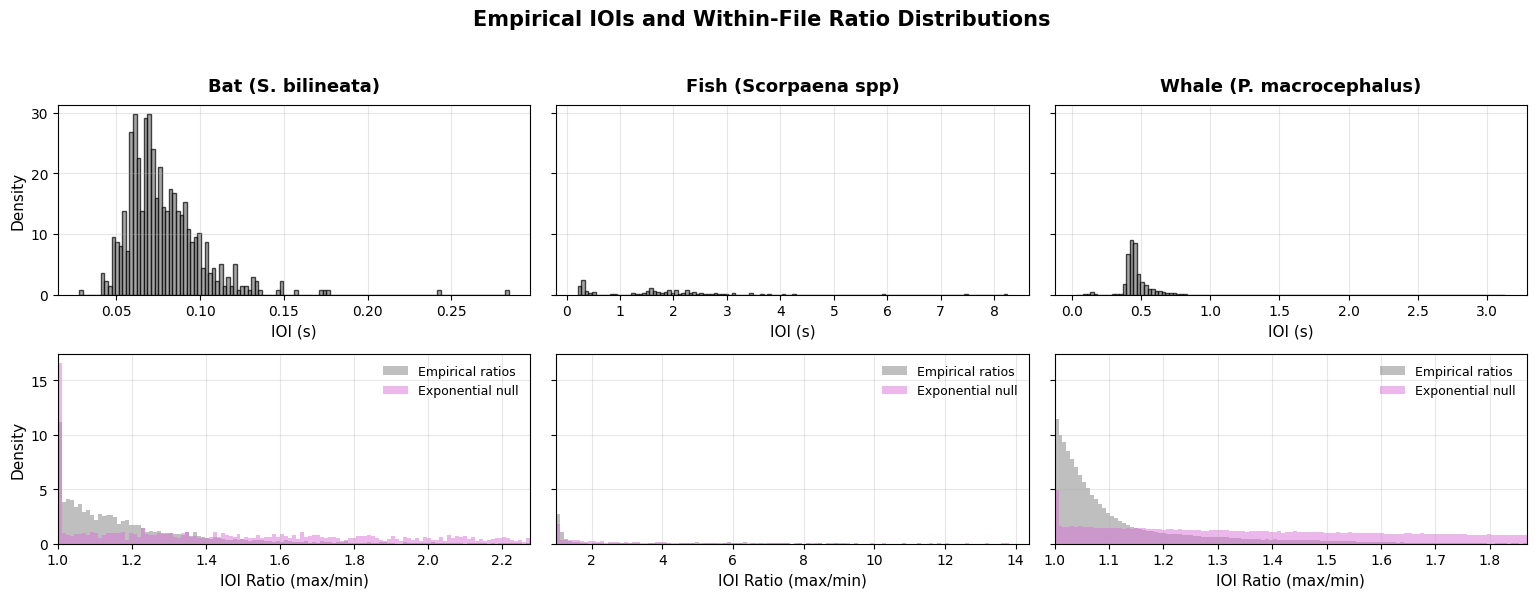

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os


def plot_ratio_panel_for_folders(
    folder_dict,
    bins=80,
    random_seed=42,
    max_ratio_percentile=99,
):
    """
    Creates a 2xN panel (empirical IOIs and ratio distributions)
    for multiple datasets (folders). Ratios are computed *within*
    each CSV file, never across files.

    Parameters
    ----------
    folder_dict : dict
        {"Label": "/path/to/folder", ...}
    bins : int
        Number of histogram bins.
    random_seed : int
        RNG seed for reproducibility.
    max_ratio_percentile : float
        Upper percentile cutoff for ratio outliers.
    """
    rng = np.random.default_rng(random_seed)
    n = len(folder_dict)
    fig, axs = plt.subplots(2, n, figsize=(5.2 * n, 6), sharey='row')

    for idx, (label, folder_path) in enumerate(folder_dict.items()):
        all_iois = []
        all_ratios = []
        all_ratios_exp = []

        # --- Alle CSVs im Ordner einlesen ---
        for file in os.listdir(folder_path):
            if not file.lower().endswith(".csv"):
                continue
            path = os.path.join(folder_path, file)
            df = pd.read_csv(path)
            if "IOI" not in df.columns:
                continue
            iois = df["IOI"].dropna().values
            if len(iois) < 2:
                continue
            all_iois.append(iois)

            # Ratios innerhalb der Datei
            r = (iois[:, None] / iois[None, :]).ravel()
            r = np.maximum(r, 1 / r)
            r = r[r < np.percentile(r, max_ratio_percentile)]
            all_ratios.append(r)

            # Nullmodell (Exponential)
            mean_ioi = np.mean(iois)
            E = rng.exponential(scale=mean_ioi, size=len(iois))
            r_exp = (E[:, None] / E[None, :]).ravel()
            r_exp = np.maximum(r_exp, 1 / r_exp)
            r_exp = r_exp[r_exp < np.percentile(r_exp, max_ratio_percentile)]
            all_ratios_exp.append(r_exp)

        if not all_iois:
            print(f"⚠️ No valid data in {folder_path}")
            continue

        iois_all = np.concatenate(all_iois)
        ratios_all = np.concatenate(all_ratios)
        ratios_exp_all = np.concatenate(all_ratios_exp)

        # --- Achsen ---
        x_min = 1
        x_max = np.percentile(ratios_all, max_ratio_percentile)
        bins_lin = np.linspace(x_min, x_max, bins)

        # === Obere Zeile: IOI-Verteilung ===
        ax1 = axs[0, idx]
        ax1.hist(iois_all, bins=bins, density=True, alpha=0.7, color="gray", edgecolor="black")
        ax1.set_title(label, fontsize=13, weight="bold", pad=10)
        if idx == 0:
            ax1.set_ylabel("Density", fontsize=11)
        ax1.set_xlabel("IOI (s)", fontsize=11)
        ax1.grid(alpha=0.3)

        # === Untere Zeile: Ratio-Verteilung ===
        ax2 = axs[1, idx]
        ax2.hist(ratios_all, bins=bins_lin, density=True, alpha=0.5, color="gray", label="Empirical ratios")
        ax2.hist(ratios_exp_all, bins=bins_lin, density=True, alpha=0.5, color="orchid", label="Exponential null")
        ax2.set_xlim(x_min, x_max)
        if idx == 0:
            ax2.set_ylabel("Density", fontsize=11)
        ax2.set_xlabel("IOI Ratio (max/min)", fontsize=11)
        ax2.grid(alpha=0.3)
        ax2.legend(fontsize=9, frameon=False, loc="upper right")

    fig.suptitle("Empirical IOIs and Within-File Ratio Distributions", fontsize=15, weight="bold", y=0.99)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# === Beispielaufruf ===
plot_ratio_panel_for_folders(
    {
        "Bat (S. bilineata)": "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Bat Saccopteryx bilineata (S_bil)",
        "Fish (Scorpaena spp)": "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Kwa-Sounds Scorpaena spp",
        "Whale (P. macrocephalus)": "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Sperm whale Physeter macrocephalus (sw)",
    },
    bins=120,
)


KeyboardInterrupt: 

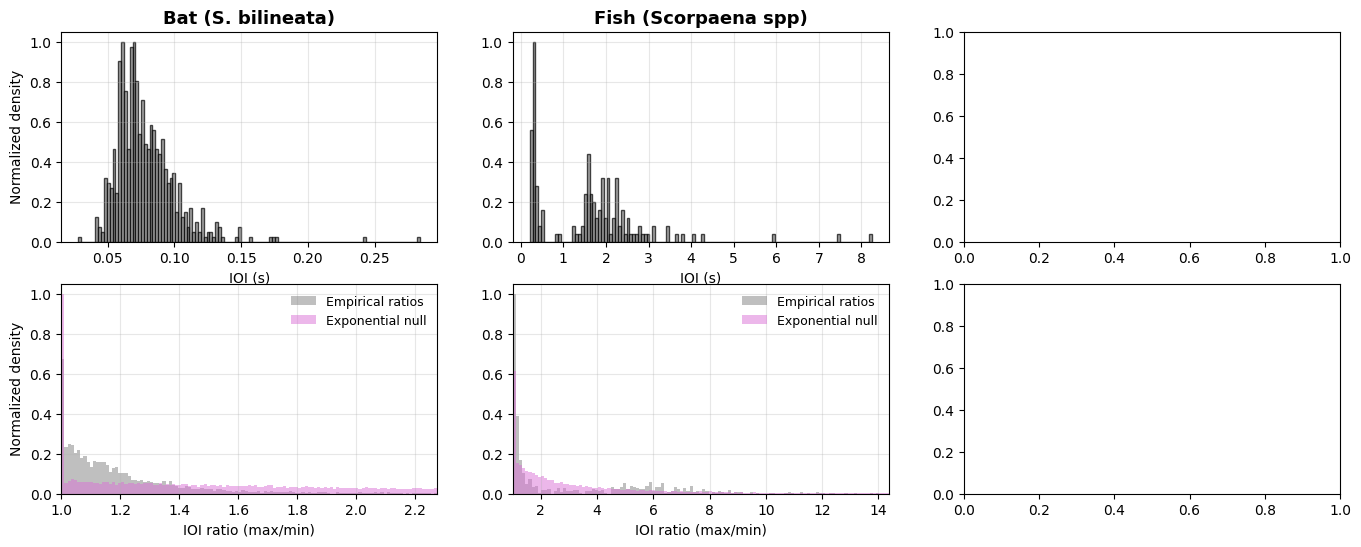

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from pathlib import Path
import sys

# übergeordneten Ordner hinzufügen
sys.path.append(str(Path("..").resolve()))  # geht eine Ebene hoch

import importlib
import proximitylib.proximity as prox
from tabulate import tabulate
importlib.reload(prox)

def plot_ratio_panel_from_folders_with_nulls(
    folder_dict,
    bins=100,
    num_null_sequences=100,
    random_seed=42,
    max_ratio_percentile=99,
    use_proximity_weight=False,
    param_choice=1,
):
    """
    Creates a 2×N panel (empirical IOIs + ratio distributions) for multiple datasets.
    Null models are generated via prox.generate_null_sequences().
    Ratios are computed within files, and distributions normalized per dataset.

    Parameters
    ----------
    folder_dict : dict
        {"Label": "/path/to/folder", ...}
    bins : int
        Histogram bins.
    num_null_sequences : int
        Number of exponential null sequences per file.
    random_seed : int
        RNG seed.
    max_ratio_percentile : float
        Percentile cutoff for extreme ratios.
    use_proximity_weight : bool
        If True, apply proximity_max_freq_gaussian_table() as weighting to ratios.
    param_choice : int
        Parameter set for proximity weighting (if used).
    """

    rng = np.random.default_rng(random_seed)
    n = len(folder_dict)
    params = prox.param_sets[param_choice]

    fig, axs = plt.subplots(2, n, figsize=(5.5 * n, 6), sharey=False)

    for idx, (label, folder_path) in enumerate(folder_dict.items()):
        all_iois, all_ratios, all_ratios_null = [], [], []

        for file in os.listdir(folder_path):
            if not file.lower().endswith(".csv"):
                continue
            df = pd.read_csv(os.path.join(folder_path, file))
            if "IOI" not in df.columns:
                continue
            iois = df["IOI"].dropna().values
            if len(iois) < 2:
                continue

            # --- Real ratios ---
            r = (iois[:, None] / iois[None, :]).ravel()
            r = np.maximum(r, 1 / r)
            r = r[r < np.percentile(r, max_ratio_percentile)]
            all_ratios.append(r)
            all_iois.append(iois)

            # --- Null sequences über prox.generate_null_sequences() ---
            nulls = prox.generate_null_sequences(iois, num_sequences=num_null_sequences, models=("expon",), seed=random_seed)
            null_iois = nulls["expon"]

            null_ratios_list = []
            for sim_iois in null_iois:
                rr = (sim_iois[:, None] / sim_iois[None, :]).ravel()
                rr = np.maximum(rr, 1 / rr)
                rr = rr[rr < np.percentile(rr, max_ratio_percentile)]
                if use_proximity_weight:
                    # apply proximity weighting (optional, more biologically meaningful)
                    weights, _ = prox.proximity_max_freq_gaussian_table(rr, **params)
                    rr = np.repeat(rr, np.clip((weights * 10).astype(int), 1, None))  # weight ratios
                null_ratios_list.append(rr)

            all_ratios_null.append(np.concatenate(null_ratios_list))

        if not all_iois:
            print(f"⚠️ No valid IOI data in {folder_path}")
            continue

        iois_all = np.concatenate(all_iois)
        ratios_all = np.concatenate(all_ratios)
        ratios_null_all = np.concatenate(all_ratios_null)

        # --- Histogram-Bereiche ---
        x_min = 1
        x_max = np.percentile(ratios_all, max_ratio_percentile)
        bins_lin = np.linspace(x_min, x_max, bins)

        # === Oberes Panel: IOI ===
        ax1 = axs[0, idx]
        h_ioi, e_ioi = np.histogram(iois_all, bins=bins, density=True)
        ax1.bar((e_ioi[:-1] + e_ioi[1:]) / 2, h_ioi / h_ioi.max(), width=np.diff(e_ioi),
                color="gray", alpha=0.7, edgecolor="black")
        ax1.set_title(label, fontsize=13, weight="bold")
        ax1.set_xlabel("IOI (s)")
        if idx == 0:
            ax1.set_ylabel("Normalized density")
        ax1.grid(alpha=0.3)

        # === Unteres Panel: Ratios ===
        ax2 = axs[1, idx]
        h_emp, e_emp = np.histogram(ratios_all, bins=bins_lin, density=True)
        h_null, _ = np.histogram(ratios_null_all, bins=bins_lin, density=True)

        scale = max(h_emp.max(), h_null.max())
        h_emp /= scale
        h_null /= scale

        ax2.bar((e_emp[:-1] + e_emp[1:]) / 2, h_emp, width=np.diff(e_emp),
                alpha=0.5, color="gray", label="Empirical ratios", edgecolor="none")
        ax2.bar((e_emp[:-1] + e_emp[1:]) / 2, h_null, width=np.diff(e_emp),
                alpha=0.5, color="orchid", label="Exponential null", edgecolor="none")

        ax2.set_xlim(x_min, x_max)
        ax2.set_xlabel("IOI ratio (max/min)")
        if idx == 0:
            ax2.set_ylabel("Normalized density")
        ax2.grid(alpha=0.3)
        ax2.legend(fontsize=9, frameon=False, loc="upper right")

    fig.suptitle("Empirical IOIs and Within-File Ratio Distributions\n(nulls via proximitylib)", fontsize=15, weight="bold", y=0.99)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# === Beispielaufruf ===
plot_ratio_panel_from_folders_with_nulls(
    {
        "Bat (S. bilineata)": "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Bat Saccopteryx bilineata (S_bil)",
        "Fish (Scorpaena spp)": "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Kwa-Sounds Scorpaena spp",
        "Whale (P. macrocephalus)": "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Sperm whale Physeter macrocephalus (sw)",
    },
    bins=120,
    num_null_sequences=200,
    use_proximity_weight=False,  # True = gewichtet nach deiner Proximity-Kurve
)


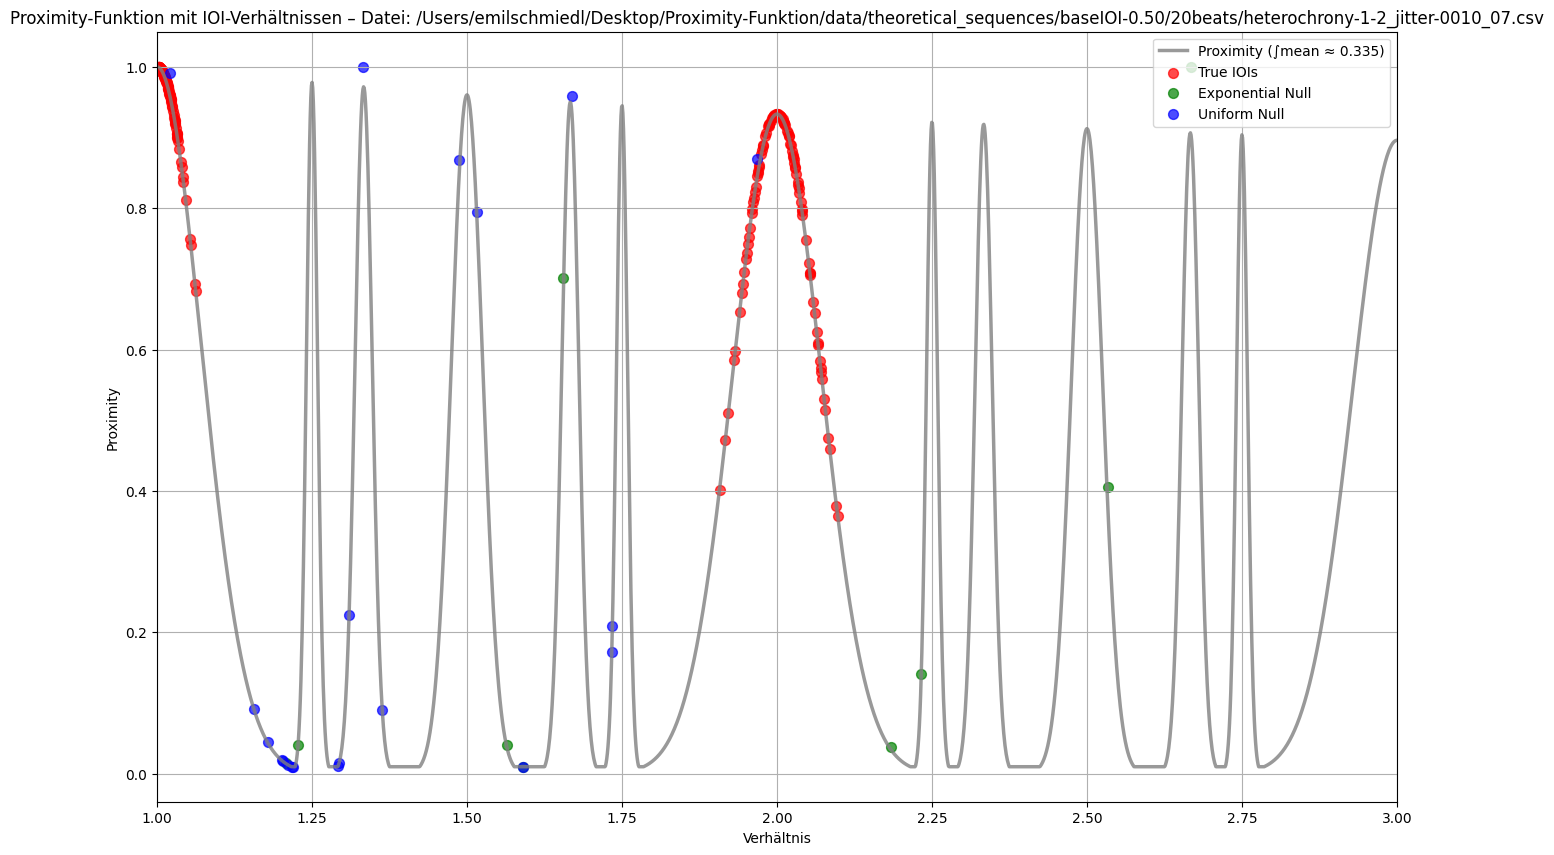

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import simpson

# === Proximity-Funktion ===
def proximity_max_freq_gaussian(
    x,
    sharpness_base=14.0,
    sharpness_growth=0,
    decay=0.1,
    max_freq=4,
    x_max=None,
    weight_exponent=0.0,
    freq_sharpness_exp=1.5,
    output_max=1.0,
    threshold=0.01,
):
    x = np.array(x, dtype=float)
    if x_max is None:
        x_max = int(np.ceil(np.max(x)))
    N = len(x)
    result = np.zeros(N)
    best_frac = [(0, 0)] * N

    for f in range(1, max_freq + 1):
        k_vals = np.arange(f, x_max * f + 1)
        mu_all = k_vals / f
        sharpness_f = sharpness_base * (f ** freq_sharpness_exp)
        sigma_all = 1.0 / (sharpness_f * (k_vals ** sharpness_growth) + 1e-9)
        weight_f = 1.0 / (f ** weight_exponent)
        mu_decay_all = 1.0 / (mu_all ** decay)

        diff = x[:, None] - mu_all[None, :]
        g = weight_f * mu_decay_all[None, :] * np.exp(-0.5 * (diff / sigma_all[None, :])**2)
        best_idx = np.argmax(g, axis=1)
        best_val = g[np.arange(N), best_idx]
        update_idx = best_val > result
        result[update_idx] = best_val[update_idx]
        for idx in np.where(update_idx)[0]:
            best_frac[idx] = (int(k_vals[best_idx[idx]]), f)

    if result.max() > 0:
        result /= result.max()
    result *= output_max
    result[result < threshold] = threshold
    return result, best_frac

# === Nullmodell-Generator ===
def build_null_ratios(n, model, rng, iois):
    if model == "expon":
        sim_iois = rng.exponential(scale=np.mean(iois), size=n)
    elif model == "uniform":
        sim_iois = rng.uniform(np.min(iois), np.max(iois), size=n)
    else:
        raise ValueError("Unbekanntes Modell: choose from 'expon' or 'uniform'")

    triu_idx = np.triu_indices(n, k=1)
    ratios = np.maximum(sim_iois[:, None], sim_iois[None, :]) / np.minimum(sim_iois[:, None], sim_iois[None, :])
    return ratios[triu_idx]

# === Wrapper ===
def generate_ratios(iois, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    n = len(iois)
    # Gleich viele Ratios aus Nullmodellen ziehen
    k = len(iois)
    expon = build_null_ratios(n, "expon", rng, iois)
    uniform = build_null_ratios(n, "uniform", rng, iois)
    # Falls zu viele Ratios: auf gleiche Anzahl zufällig reduzieren
    expon = rng.choice(expon, size=k, replace=False)
    uniform = rng.choice(uniform, size=k, replace=False)
    return expon, uniform

# === Beispielplot ===
file = "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/theoretical_sequences/baseIOI-0.50/20beats/heterochrony-1-2_jitter-0010_07.csv"  # CSV mit Spalte 'IOI'
df = pd.read_csv(file)
iois = df["IOI"].dropna().values

# Drei Ratio-Sets erzeugen
rng = np.random.default_rng(42)
expon, uniform = generate_ratios(iois, rng)

# Echte Ratios (aus den Originaldaten)
n = len(iois)
triu_idx = np.triu_indices(n, k=1)
true_ratios = (np.maximum(iois[:, None], iois[None, :]) / np.minimum(iois[:, None], iois[None, :]))[triu_idx]

# Dynamische Plot-Grenzen
all_ratios = np.concatenate([expon, uniform, true_ratios])
x_min = max(1.0, all_ratios.min() * 0.95)
x_max = all_ratios.max() * 1.05

# Proximity-Kurve berechnen (vektorisiert)
x_range = np.linspace(1, 3, 2000)
y_curve, _ = proximity_max_freq_gaussian(x_range)
mean_prox = simpson(y_curve, x=x_range) / (x_range[-1] - x_range[0])

# === Plot ===
plt.figure(figsize=(16, 10))
plt.plot(
    x_range,
    y_curve,
    label=f"Proximity (∫mean ≈ {mean_prox:.3f})",
    alpha=0.8,
    color="gray",
    linewidth=2.5
)

# Punkte einzeichnen
for ratios, color, label in zip(
    [true_ratios, expon, uniform],
    ["red", "green", "blue"],
    ["True IOIs", "Exponential Null", "Uniform Null"]):
    y_vals, _ = proximity_max_freq_gaussian(ratios)
    plt.scatter(ratios, y_vals, s=50, alpha=0.7, color=color, label=label, marker='o')

plt.title(f"Proximity-Funktion mit IOI-Verhältnissen – Datei: {file}")
plt.xlabel("Verhältnis")
plt.ylabel("Proximity")
plt.xlim(1, 3)
plt.legend()
plt.grid(True)
plt.show()

✅ Panel gespeichert unter: peak_matrices_panel.png


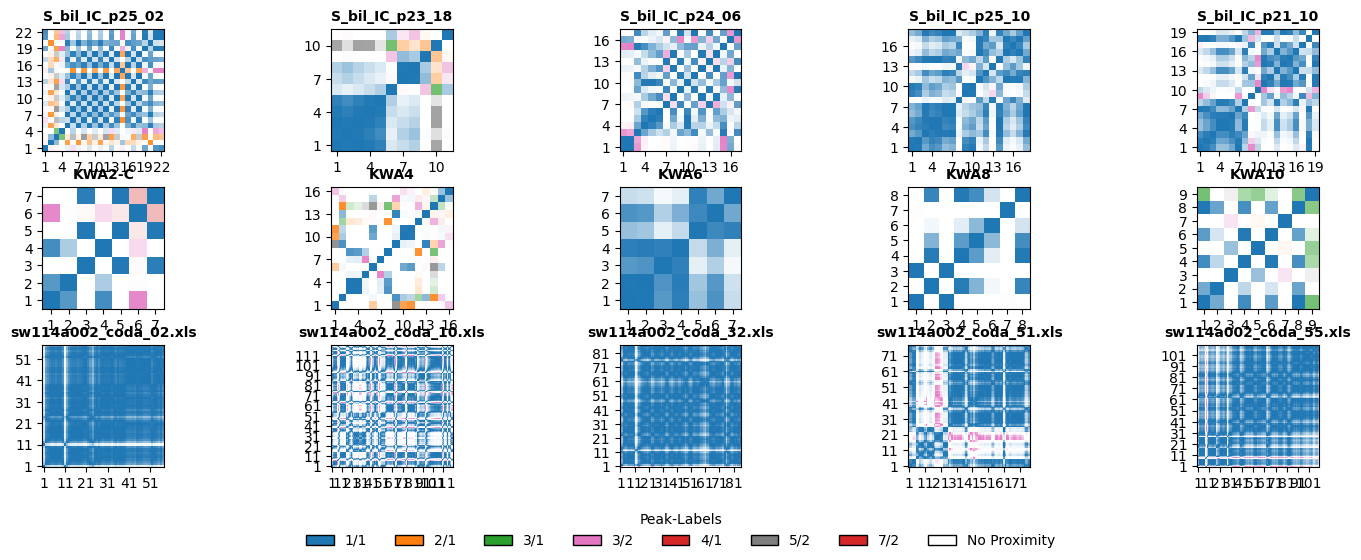

In [ ]:
# matrizen
from pathlib import Path
import sys

# übergeordneten Ordner hinzufügen
sys.path.append(str(Path("..").resolve()))  # geht eine Ebene hoch

import importlib
import proximitylib.proximity as prox
from tabulate import tabulate
importlib.reload(prox)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from fractions import Fraction
from proximitylib.proximity import build_pairwise_proximity_df, proximity_max_freq_gaussian_table, param_sets
import math

def panel_peak_matrices_2rows(file_paths, param_choice=0, figsize=(20, 14), save_path=None):
    """
    Paperreifes Panel mit Peakvalue-Matrizen für mehrere Dateien in 2 Reihen.

    Parameters
    ----------
    file_paths : list of str | Path
        Liste von vollständigen Pfaden zu CSV-Dateien mit 'IOI'-Spalte.
    param_choice : int | str
        Param-Dict aus param_sets.
    figsize : tuple
        Figurgröße.
    save_path : str | Path | None
        Optionaler Speicherort.
    """
    n_files = len(file_paths)
    n_cols = math.ceil(n_files / 2)
    n_rows = 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, constrained_layout=False)
    axes = axes.flatten()

    params = param_sets[param_choice]

    # Farben für Peak-Labels (Basisfarben)
    tab10 = plt.cm.tab10.colors
    fixed_colors = {
        "1/1": tab10[0], "2/1": tab10[1], "3/1": tab10[2], "4/1": tab10[3], "5/1": tab10[4],
        "1/2": tab10[5], "3/2": tab10[6], "5/2": tab10[7], "1/3": tab10[8], "2/3": tab10[9],
        "4/3": (0.5, 0.0, 0.5)
    }

    # -------------------------
    # Alle Peak-Labels über alle Dateien sammeln (nur tatsächlich genutzte Labels)
    # -------------------------
    all_peak_labels = set()
    for path in file_paths:
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        df_pairs, _, _ = build_pairwise_proximity_df(iois, params)
        # explizit als string, NaN/None ausschließen
        labels_here = pd.Series(df_pairs["peak_label"].astype(str)).dropna().unique()
        # evtl. leere Strings entfernen
        labels_here = [lab for lab in labels_here if lab != "" and lab.lower() != "nan"]
        all_peak_labels.update(labels_here)
    all_peak_labels = sorted(all_peak_labels)

    # Falls du möchtest, dass "Keine Proximity" immer dabei ist, sicherstellen:
    if "No Proximity" not in all_peak_labels:
        all_peak_labels.insert(0, "No Proximity")
    
    # Farben zuordnen
    label_to_color = {}
    for idx, lab in enumerate(all_peak_labels):
        if lab == "No Proximity":
            label_to_color[lab] = (1,1,1)  # weiß
        elif lab in fixed_colors:
            label_to_color[lab] = fixed_colors[lab]
        else:
            color = plt.cm.tab20(idx % 20)
            label_to_color[lab] = color

    # Dateien plotten
    for ax, path in zip(axes, file_paths):
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        n = len(iois)

        df_pairs, ratios, prox_mat = build_pairwise_proximity_df(iois, params)
        pivot_vals = df_pairs.pivot(index="i", columns="j", values="prox_value") * 100
        pivot_labels = df_pairs.pivot(index="i", columns="j", values="peak_label")

        for (i, j), val in np.ndenumerate(pivot_vals.values):
            label = pivot_labels.iloc[i, j]
            base_color = label_to_color.get(label, (0.8, 0.8, 0.8))
            alpha = val / 100 if not np.isnan(val) else 0
            color = (*base_color[:3], alpha)
            ax.add_patch(plt.Rectangle([j, i], 1, 1, facecolor=color, edgecolor='none'))
            if n <= 2 and not np.isnan(val):
                ax.text(j+0.5, i+0.5, f"{float(val.item()):.1f}", ha='center', va='center', fontsize=6, color="black")

        ax.set_xlim(0, n)
        ax.set_ylim(0, n)
        ax.set_aspect('equal')

        if len(iois) <= 10:
            ax.set_xticks(np.arange(n) + 0.5)
            ax.set_yticks(np.arange(n) + 0.5)
            ax.set_xticklabels(np.arange(1, n+1))
            ax.set_yticklabels(np.arange(1, n+1))
        elif len(iois) <= 30:
            step = 3
            ax.set_xticks(np.arange(0, n, step) + 0.5)
            ax.set_yticks(np.arange(0, n, step) + 0.5)
            ax.set_xticklabels(np.arange(1, n+1, step))
            ax.set_yticklabels(np.arange(1, n+1, step))
        else: 
            step = 10
            ax.set_xticks(np.arange(0, n, step) + 0.5)
            ax.set_yticks(np.arange(0, n, step) + 0.5)
            ax.set_xticklabels(np.arange(1, n+1, step))
            ax.set_yticklabels(np.arange(1, n+1, step))

        ax.set_title(Path(path).stem, fontsize=10, fontweight='bold')

    # Gemeinsame Legende (nur für die tatsächlich verwendeten Labels)
    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=label_to_color[lab], edgecolor='black')
               for lab in all_peak_labels]
    labels = all_peak_labels  # in gleicher Reihenfolge
    fig.subplots_adjust(bottom=0.15, hspace=0.3)
    fig.legend(handles, labels, loc='lower center', ncol=min(len(labels), 10),
               fontsize=10, title="Peak-Labels", frameon=False)

    # Achsen für leere Plätze deaktivieren
    for ax in axes[n_files:]:
        ax.axis('off')

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Panel gespeichert unter: {save_path}")

    plt.show()

files = [
    "../data/ergebnis-tabellen/heterochrony-1-2/heterochrony-1-2_jitter-0050_04.csv",
    "../data/ergebnis-tabellen/isochrony_small-jitter/isochrony_jitter-0001_04.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/random_exponential_03.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/isochrony_drift.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/jitter_middle-0050_02.csv",
    "../data/ergebnis-tabellen/heterochrony-2-3/heterochrony-2-3_jitter-0050_06.csv",
    "../data/ergebnis-tabellen/isochrony_big-jitter/isochrony_jitter-0050_03.csv",
    "../data/ergebnis-tabellen/random uniform/random_uniform_04.csv",
    "../data/ergebnis-tabellen/accelerando/accelerando.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/tempo_shift_onlyioi-jitter-0050_06.csv"
]

panel_peak_matrices_2rows(files, param_choice=3, figsize=(18, 6), save_path="peak_matrices_panel.png")


✅ Panel gespeichert unter: peak_matrices_panel.png


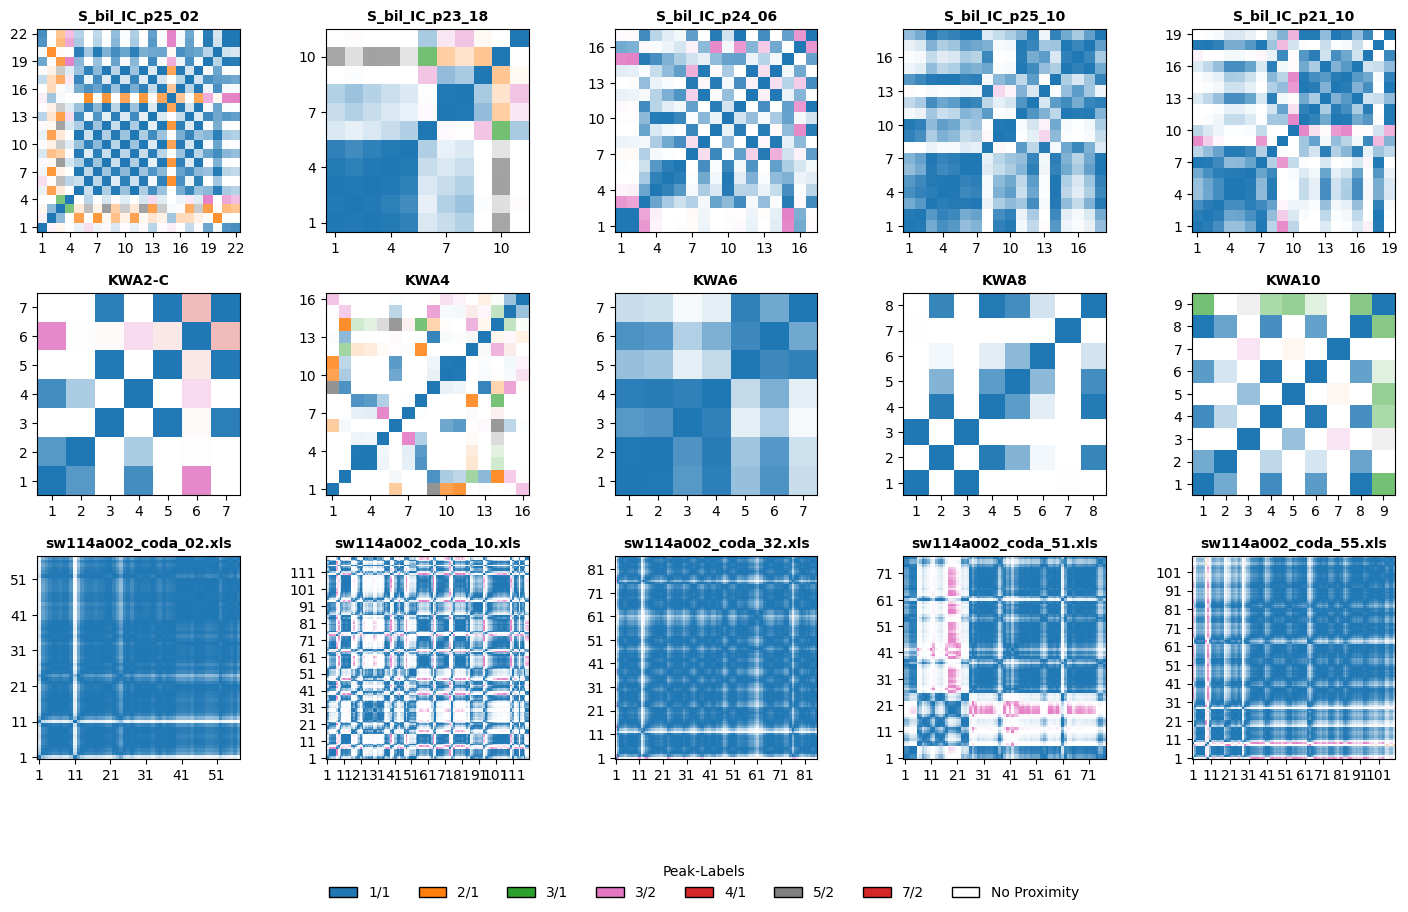

In [ ]:
# matrizen
from pathlib import Path
import sys

# übergeordneten Ordner hinzufügen
sys.path.append(str(Path("..").resolve()))  # geht eine Ebene hoch

import importlib
import proximitylib.proximity as prox
from tabulate import tabulate
importlib.reload(prox)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from fractions import Fraction
from proximitylib.proximity import build_pairwise_proximity_df, proximity_max_freq_gaussian_table, param_sets
import math

def panel_peak_matrices_2rows(file_paths, param_choice=0, figsize=(20, 20), save_path=None):
    """
    Paperreifes Panel mit Peakvalue-Matrizen für mehrere Dateien in 2 Reihen.

    Parameters
    ----------
    file_paths : list of str | Path
        Liste von vollständigen Pfaden zu CSV-Dateien mit 'IOI'-Spalte.
    param_choice : int | str
        Param-Dict aus param_sets.
    figsize : tuple
        Figurgröße.
    save_path : str | Path | None
        Optionaler Speicherort.
    """
    n_files = len(file_paths)
    n_cols = math.ceil(n_files / 3)
    n_rows = 3
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, constrained_layout=False)
    axes = axes.flatten()

    params = param_sets[param_choice]

    # Farben für Peak-Labels (Basisfarben)
    tab10 = plt.cm.tab10.colors
    fixed_colors = {
        "1/1": tab10[0], "2/1": tab10[1], "3/1": tab10[2], "4/1": tab10[3], "5/1": tab10[4],
        "1/2": tab10[5], "3/2": tab10[6], "5/2": tab10[7], "1/3": tab10[8], "2/3": tab10[9],
        "4/3": (0.5, 0.0, 0.5)
    }

    # -------------------------
    # Alle Peak-Labels über alle Dateien sammeln (nur tatsächlich genutzte Labels)
    # -------------------------
    all_peak_labels = set()
    for path in file_paths:
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        df_pairs, _, _ = build_pairwise_proximity_df(iois, params)
        # explizit als string, NaN/None ausschließen
        labels_here = pd.Series(df_pairs["peak_label"].astype(str)).dropna().unique()
        # evtl. leere Strings entfernen
        labels_here = [lab for lab in labels_here if lab != "" and lab.lower() != "nan"]
        all_peak_labels.update(labels_here)
    all_peak_labels = sorted(all_peak_labels)

    # Falls du möchtest, dass "Keine Proximity" immer dabei ist, sicherstellen:
    if "No Proximity" not in all_peak_labels:
        all_peak_labels.insert(0, "No Proximity")
    
    # Farben zuordnen
    label_to_color = {}
    for idx, lab in enumerate(all_peak_labels):
        if lab == "No Proximity":
            label_to_color[lab] = (1,1,1)  # weiß
        elif lab in fixed_colors:
            label_to_color[lab] = fixed_colors[lab]
        else:
            color = plt.cm.tab20(idx % 20)
            label_to_color[lab] = color

    # Dateien plotten
    for ax, path in zip(axes, file_paths):
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        n = len(iois)

        df_pairs, ratios, prox_mat = build_pairwise_proximity_df(iois, params)
        pivot_vals = df_pairs.pivot(index="i", columns="j", values="prox_value") * 100
        pivot_labels = df_pairs.pivot(index="i", columns="j", values="peak_label")

        for (i, j), val in np.ndenumerate(pivot_vals.values):
            label = pivot_labels.iloc[i, j]
            base_color = label_to_color.get(label, (0.8, 0.8, 0.8))
            alpha = val / 100 if not np.isnan(val) else 0
            color = (*base_color[:3], alpha)
            ax.add_patch(plt.Rectangle([j, i], 1, 1, facecolor=color, edgecolor='none'))
            if n <= 2 and not np.isnan(val):
                ax.text(j+0.5, i+0.5, f"{float(val.item()):.1f}", ha='center', va='center', fontsize=6, color="black")

        ax.set_xlim(0, n)
        ax.set_ylim(0, n)
        ax.set_aspect('equal')

        if len(iois) <= 10:
            ax.set_xticks(np.arange(n) + 0.5)
            ax.set_yticks(np.arange(n) + 0.5)
            ax.set_xticklabels(np.arange(1, n+1))
            ax.set_yticklabels(np.arange(1, n+1))
        elif len(iois) <= 30:
            step = 3
            ax.set_xticks(np.arange(0, n, step) + 0.5)
            ax.set_yticks(np.arange(0, n, step) + 0.5)
            ax.set_xticklabels(np.arange(1, n+1, step))
            ax.set_yticklabels(np.arange(1, n+1, step))
        else: 
            step = 10
            ax.set_xticks(np.arange(0, n, step) + 0.5)
            ax.set_yticks(np.arange(0, n, step) + 0.5)
            ax.set_xticklabels(np.arange(1, n+1, step))
            ax.set_yticklabels(np.arange(1, n+1, step))

        ax.set_title(Path(path).stem, fontsize=10, fontweight='bold')

    # Gemeinsame Legende (nur für die tatsächlich verwendeten Labels)
    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=label_to_color[lab], edgecolor='black')
               for lab in all_peak_labels]
    labels = all_peak_labels  # in gleicher Reihenfolge
    fig.subplots_adjust(bottom=0.05, hspace=0.3)
    fig.legend(handles, labels, loc='lower center', ncol=min(len(labels), 10),
               fontsize=10, title="Peak-Labels", frameon=False)

    # Achsen für leere Plätze deaktivieren
    for ax in axes[n_files:]:
        ax.axis('off')

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Panel gespeichert unter: {save_path}")

    plt.show()

files = [
    "../data/ergebnis-tabellen/heterochrony-1-2/heterochrony-1-2_jitter-0050_04.csv",
    "../data/ergebnis-tabellen/isochrony_small-jitter/isochrony_jitter-0001_04.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/random_exponential_03.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/isochrony_drift.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/jitter_middle-0050_02.csv",
    "../data/ergebnis-tabellen/heterochrony-2-3/heterochrony-2-3_jitter-0050_06.csv",
    "../data/ergebnis-tabellen/isochrony_big-jitter/isochrony_jitter-0050_03.csv",
    "../data/ergebnis-tabellen/random uniform/random_uniform_04.csv",
    "../data/ergebnis-tabellen/accelerando/accelerando.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/tempo_shift_onlyioi-jitter-0050_06.csv"
]

animals = [
    "../data/Bat Saccopteryx bilineata (S_bil)/S_bil_IC_p25_02.csv",
    "../data/Bat Saccopteryx bilineata (S_bil)/S_bil_IC_p23_18.csv",
    "../data/Bat Saccopteryx bilineata (S_bil)/S_bil_IC_p24_06.csv",
    "../data/Bat Saccopteryx bilineata (S_bil)/S_bil_IC_p25_10.csv",
    "../data/Bat Saccopteryx bilineata (S_bil)/S_bil_IC_p21_10.csv",
    "../data/Kwa-Sounds Scorpaena spp/KWA2-C.csv",
    "../data/Kwa-Sounds Scorpaena spp/KWA4.csv",
    "../data/Kwa-Sounds Scorpaena spp/KWA6.csv",
    "../data/Kwa-Sounds Scorpaena spp/KWA8.csv",
    "../data/Kwa-Sounds Scorpaena spp/KWA10.csv",
    "../data/Sperm whale Physeter macrocephalus (sw)/sw114a002_coda_02.xls.csv",
    "../data/Sperm whale Physeter macrocephalus (sw)/sw114a002_coda_10.xls.csv",
    "../data/Sperm whale Physeter macrocephalus (sw)/sw114a002_coda_32.xls.csv",
    "../data/Sperm whale Physeter macrocephalus (sw)/sw114a002_coda_51.xls.csv",
    "../data/Sperm whale Physeter macrocephalus (sw)/sw114a002_coda_55.xls.csv"
]

panel_peak_matrices_2rows(animals, param_choice=3, figsize=(18, 10), save_path="animals_panel.png")
